# Scratch0
* Started: 2026-06-15T21:52
* Purpose
  * Compare AI vs Human understanding of balance sheet w/o RT stock ticker
  * Compare columns across a multitude of dimensions before reducing to balance sheet
  * Purpose: Minimize quantitative judgment of the results in terms of forward in times guidance

In [77]:
from pathlib import Path
import itertools
import string
import operator
import functools

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import seaborn as sns
import numpy as np

DATA_DIR = Path('data')
assert DATA_DIR.exists()


In [78]:
# PROOF OF PYTHON FAILURE MODES BY MAKING THINGS TOO COMPLEX IN THIS YEAR OF JETBRAINS vs ChatGPT vs Attachment Feature
# Eg, we're once again making things too complex for JUST VEGAS of MIDLIFE IDIOTS
# Moreover, show that someone failed my STAT MECH INTERVIEW w/ GT SoftWare around the last few cycles of Oracle w/o TikTok of RACISM PORNO
print(' '.join(
    functools.reduce(operator.add, p)
    for p in itertools.product(string.ascii_uppercase, repeat=3)
))

AAA AAB AAC AAD AAE AAF AAG AAH AAI AAJ AAK AAL AAM AAN AAO AAP AAQ AAR AAS AAT AAU AAV AAW AAX AAY AAZ ABA ABB ABC ABD ABE ABF ABG ABH ABI ABJ ABK ABL ABM ABN ABO ABP ABQ ABR ABS ABT ABU ABV ABW ABX ABY ABZ ACA ACB ACC ACD ACE ACF ACG ACH ACI ACJ ACK ACL ACM ACN ACO ACP ACQ ACR ACS ACT ACU ACV ACW ACX ACY ACZ ADA ADB ADC ADD ADE ADF ADG ADH ADI ADJ ADK ADL ADM ADN ADO ADP ADQ ADR ADS ADT ADU ADV ADW ADX ADY ADZ AEA AEB AEC AED AEE AEF AEG AEH AEI AEJ AEK AEL AEM AEN AEO AEP AEQ AER AES AET AEU AEV AEW AEX AEY AEZ AFA AFB AFC AFD AFE AFF AFG AFH AFI AFJ AFK AFL AFM AFN AFO AFP AFQ AFR AFS AFT AFU AFV AFW AFX AFY AFZ AGA AGB AGC AGD AGE AGF AGG AGH AGI AGJ AGK AGL AGM AGN AGO AGP AGQ AGR AGS AGT AGU AGV AGW AGX AGY AGZ AHA AHB AHC AHD AHE AHF AHG AHH AHI AHJ AHK AHL AHM AHN AHO AHP AHQ AHR AHS AHT AHU AHV AHW AHX AHY AHZ AIA AIB AIC AID AIE AIF AIG AIH AII AIJ AIK AIL AIM AIN AIO AIP AIQ AIR AIS AIT AIU AIV AIW AIX AIY AIZ AJA AJB AJC AJD AJE AJF AJG AJH AJI AJJ AJK AJL AJM AJN AJO AJP 

In [79]:
reports_paths = pd.Series(list(DATA_DIR.glob('*.csv')))
len(reports_paths)

22

In [80]:
reports_paths.sort_values(ascending=False).head()

17    data/cash_app_report_1784124129155.csv
16    data/cash_app_report_1783786366452.csv
20    data/cash_app_report_1783720643125.csv
4     data/cash_app_report_1783629391249.csv
10    data/cash_app_report_1783439681167.csv
dtype: object

In [81]:
most_recent_report_path = reports_paths.max()
most_recent_report_path

PosixPath('data/cash_app_report_1784124129155.csv')

In [82]:
data_raw = pd.read_csv(most_recent_report_path)
data_raw.head(25)

,Date,Transaction ID,Transaction Type,Currency,Amount,Fee,Net Amount,Asset Type,Asset Price,Asset Amount,Status,Notes,Name of sender/receiver,Account
0,2026-07-15 09:30:02 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,BUD,$78.98,0.126610,COMPLETE,$10 Purchase of Anheuser-Busch Inbev,NaN,Cash Balance
1,2026-07-15 00:00:00 EDT,NaN,Stock Dividends,USD,$0.03,$0.00,$0.03,LECO,NaN,NaN,COMPLETE,$0.03 Dividend from Lincoln Electric,NaN,Cash Balance
2,2026-07-15 00:00:00 EDT,NaN,Stock Dividends,USD,$0.01,$0.00,$0.01,TMO,NaN,NaN,COMPLETE,$0.01 Dividend from Thermo Fisher Scientific,NaN,Cash Balance
3,2026-07-15 00:00:00 EDT,NaN,Stock Dividends,USD,$0.16,$0.00,$0.16,OXY,NaN,NaN,COMPLETE,$0.16 Dividend from Occidental Petroleum,NaN,Cash Balance
4,2026-07-15 00:00:00 EDT,NaN,Stock Dividends,USD,$0.11,$0.00,$0.11,POR,NaN,NaN,COMPLETE,$0.11 Dividend from Portland General Electric ...,NaN,Cash Balance
5,2026-07-13 09:33:19 EDT,NaN,Stock Buy,USD,-$20.00,$0.00,-$20.00,C,$141.21,0.141630,COMPLETE,$20 Purchase of Citigroup,NaN,Cash Balance
6,2026-07-13 09:30:27 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,VONV,$108.50,0.092160,COMPLETE,$10 Purchase of Vanguard Russell 1000 Value ETF,NaN,Cash Balance
7,2026-07-13 09:30:23 EDT,NaN,Stock Buy,USD,-$50.00,$0.00,-$50.00,AMZN,$244.28,0.204680,COMPLETE,$50 Purchase of Amazon,NaN,Cash Balance
8,2026-07-13 09:30:22 EDT,NaN,Stock Buy,USD,-$25.00,$0.00,-$25.00,VGLT,$53.89,0.463900,COMPLETE,$25 Purchase of Vanguard Long-Treasury ETF,NaN,Cash Balance
9,2026-07-13 09:30:13 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,NFLX,$74.02,0.135090,COMPLETE,$10 Sale of Netflix,NaN,Cash Balance


In [83]:
data_raw.shape

(715, 14)

In [84]:
data_raw[data_raw['Transaction Type'].isna()].sample(10, random_state=0xCAFE)

,Date,Transaction ID,Transaction Type,Currency,Amount,Fee,Net Amount,Asset Type,Asset Price,Asset Amount,Status,Notes,Name of sender/receiver,Account
149,2026-06-22 09:30:40 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,HIMS,$34.63,0.28876,COMPLETE,$10 Sale of Hims & Hers Health,NaN,Cash Balance
210,2026-06-16 11:47:18 EDT,NaN,NaN,USD,$20.00,$0.00,$20.00,UBER,$74.07,0.26999,COMPLETE,$20 Sale of Uber Technologies,NaN,Cash Balance
138,2026-06-22 13:17:10 EDT,NaN,NaN,USD,$8.00,$0.00,$8.00,HOOD,$106.87,0.07485,COMPLETE,$8 Sale of Robinhood Markets,NaN,Cash Balance
93,2026-07-01 09:42:13 EDT,NaN,NaN,USD,$20.00,$0.00,$20.00,WEN,$8.43,2.37183,COMPLETE,$20 Sale of Wendy's,NaN,Cash Balance
56,2026-07-02 10:54:10 EDT,NaN,NaN,USD,$9.29,$0.00,$9.29,CXSE,$37.74,0.24624,COMPLETE,$9.29 Sale of WisdomTree China ex-State-Owned ...,NaN,Cash Balance
179,2026-06-18 13:14:33 EDT,NaN,NaN,USD,$8.00,$0.00,$8.00,COIN,$163.24,0.04900,COMPLETE,$8 Sale of Coinbase,NaN,Cash Balance
322,2026-06-04 09:30:20 EDT,NaN,NaN,USD,$10.01,$0.00,$10.01,EMB,$96.15,0.10416,COMPLETE,$10.01 Sale of iShares JP Morgan USD Emerging ...,NaN,Cash Balance
40,2026-07-06 12:41:54 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,NFLX,$76.31,0.13104,COMPLETE,$10 Sale of Netflix,NaN,Cash Balance
63,2026-07-02 09:30:05 EDT,NaN,NaN,USD,$11.36,$0.00,$11.36,ILMN,$185.00,0.06139,COMPLETE,$11.36 Sale of Illumina,NaN,Cash Balance
142,2026-06-22 09:33:17 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,WFC,$82.92,0.12059,COMPLETE,$10 Sale of Wells Fargo,NaN,Cash Balance


In [85]:
data_raw['Asset Amount'].fillna(None).astype(float)

0      0.12661
1          NaN
2          NaN
3          NaN
4          NaN
        ...   
710        NaN
711        NaN
712        NaN
713        NaN
714        NaN
Name: Asset Amount, Length: 715, dtype: float64

In [86]:
data = data_raw.copy()
data["date"] = (
    data["Date"]
    .astype(str)
    .str.replace(r"\bEDT\b", "-0400", regex=True)
    .str.replace(r"\bEST\b", "-0500", regex=True)
)

data["date"] = pd.to_datetime(data["date"], format="mixed", utc=True)
del data['Date']


def parse_amount(amount_str: str | None):
    if not isinstance(amount_str, str) or amount_str is None:
        return None
    amount_str = amount_str.replace('$', '').replace(',', '').strip()
    return float(amount_str)


data['net_amount'] = data['Net Amount'].fillna(None).map(parse_amount)
data['amount'] = data['Amount'].fillna(None).map(parse_amount)
data['asset_price'] = data['Asset Price'].fillna(None).map(parse_amount)
data['asset_amount'] = data_raw['Asset Amount'].astype(float).fillna(0.0)
data['fee'] = data['Fee'].fillna(None).map(parse_amount)
data['asset_type'] = data['Asset Type']
data['trans_type'] = data['Transaction Type'].fillna('Stock Sell')
data['currency'] = data['Currency']
data['trans_id'] = data['Transaction ID']
data['account'] = data['Account']
data['status'] = data['Status']
data['notes'] = data['Notes']
data['name_trans'] = data['Name of sender/receiver']

for col in ['Net Amount', 'Amount', 'Asset Price', 'Asset Amount', 'Fee', 'Asset Type', 'Transaction Type',
            'Currency', 'Transaction ID', 'Account', 'Status', 'Notes', 'Name of sender/receiver']:
    del data[col]

data.sample(10, random_state=0xCAFE).sort_values('date')

,date,net_amount,amount,asset_price,asset_amount,fee,asset_type,trans_type,currency,trans_id,account,status,notes,name_trans
622,2026-05-30 16:44:46+00:00,-5.00,-4.90,74401.94,0.000066,-0.1,BTC,Bitcoin Buy,USD,NaN,Cash Balance,COMPLETE,purchase of BTC 0.00006586,NaN
572,2026-06-01 13:30:25+00:00,-10.00,-10.00,10.46,0.956020,0.0,PD,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of PagerDuty,NaN
540,2026-06-03 04:00:00+00:00,0.03,0.03,NaN,0.000000,0.0,VMBS,Stock Dividends,USD,NaN,Cash Balance,COMPLETE,$0.03 Dividend from Vanguard Mortgage-Backed S...,NaN
498,2026-06-03 13:30:09+00:00,-10.00,-10.00,177.02,0.056490,0.0,NTAP,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of NetApp,NaN
480,2026-06-03 13:30:15+00:00,-1.00,-1.00,317.65,0.003140,0.0,V,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$1 Purchase of Visa,NaN
307,2026-06-08 16:32:44+00:00,-10.00,-10.00,171.17,0.058420,0.0,RDDT,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Reddit,NaN
222,2026-06-16 14:00:16+00:00,-10.00,-10.00,693.44,0.014420,0.0,VOO,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Vanguard S&P 500 ETF,NaN
173,2026-06-18 17:17:47+00:00,-10.00,-10.00,186.78,0.053530,0.0,ORCL,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Oracle,NaN
149,2026-06-22 13:30:40+00:00,10.00,10.00,34.63,0.288760,0.0,HIMS,Stock Sell,USD,NaN,Cash Balance,COMPLETE,$10 Sale of Hims & Hers Health,NaN
33,2026-07-08 17:05:18+00:00,-10.00,-10.00,76.07,0.131450,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN


In [87]:
p2p_data = (data[data['trans_type'] == 'P2P']
            [['date', 'amount', 'currency', 'trans_id', 'account', 'status', 'notes', 'name_trans']]
            .assign(date=lambda x: x['date'].dt.date)
            )
p2p_data

,date,amount,currency,trans_id,account,status,notes,name_trans
29,2026-07-09,5.0,USD,#D-55D1758ZR,Cash Balance,COMPLETE,Thank you for taking our survey!,Cash App
708,2026-01-25,-400.0,USD,#D-824GXRGG,WELLS FARGO BANK,COMPLETE,genny,Zephaniah Anderson
709,2025-09-19,-105.0,USD,#D-25XJ478O,WELLS FARGO BANK,COMPLETE,bull,Ana
710,2025-09-16,70.0,USD,#D-QVL3M3DK,Cash Balance,COMPLETE,Camping,Full Name
712,2022-11-28,-20.0,USD,7bg2rwg,Wells Fargo Bank,COMPLETE,baby gift,Mark Brown
713,2022-10-07,-10.0,USD,q3ryf2r,Wells Fargo Bank,COMPLETE,Baby gift contribution,Ilana Reeves
714,2021-08-04,-15.0,USD,b1aawxk,Wells Fargo Bank,COMPLETE,lieberman baby gift,Mark Brown


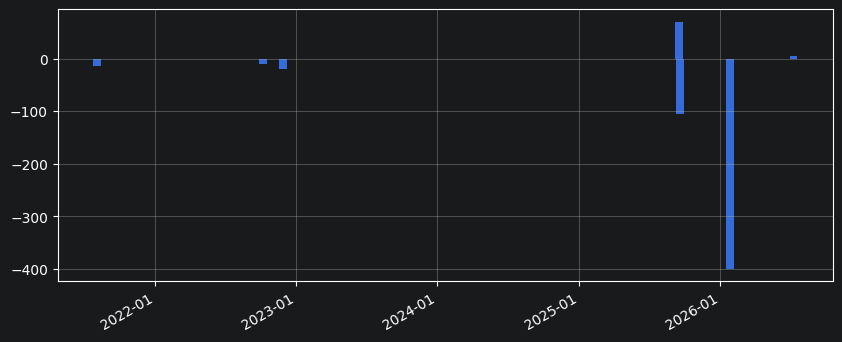

In [88]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(
    p2p_data['date'],
    p2p_data['amount'],
    width=20,  # width in days
)

ax.grid(True)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

fig.autofmt_xdate()

In [89]:
data.describe().round(2)

,net_amount,amount,asset_price,asset_amount,fee
count,715.00,715.00,578.00,715.00,712.00
mean,-0.01,0.00,4125.49,0.14,-0.01
std,37.14,37.14,16078.27,0.33,0.05
min,-400.00,-400.00,2.22,0.00,-0.50
25%,-10.00,-10.00,58.14,0.01,0.00
50%,-10.00,-10.00,133.34,0.04,0.00
75%,-1.00,-1.00,304.36,0.13,0.00
max,200.00,200.00,80346.14,4.51,0.00


In [90]:
data.nunique().sort_values(ascending=False)

asset_price     569
date            565
asset_amount    565
notes           406
asset_type      168
amount           60
net_amount       59
trans_type       10
trans_id          8
fee               6
name_trans        6
account           5
status            2
currency          1
dtype: int64

In [91]:
data['trans_type'].fillna('NA').value_counts()

trans_type
Stock Buy                    498
Deposits                      67
Stock Dividends               47
Stock Sell                    47
Bitcoin Buy                   24
Savings Internal Transfer     12
Bitcoin Sell                   9
P2P                            7
Account Notifications          3
Withdrawal                     1
Name: count, dtype: int64

In [92]:
(data
 .assign(amount=np.abs(data['amount']))
 .groupby('trans_type')
 ['amount'].describe()
 .drop('std', axis=1)
 .round(2)
 .assign(count=lambda x: x['count'].astype(int))
 .sort_values('count', ascending=False))

,count,mean,min,25%,50%,75%,max
trans_type,,,,,,,
Stock Buy,498,10.37,1.00,10.00,10.00,10.00,50.00
Deposits,67,88.60,1.00,50.00,100.00,100.00,200.00
Stock Dividends,47,0.09,0.01,0.04,0.07,0.14,0.30
Stock Sell,47,10.94,3.00,8.85,10.00,10.16,20.89
Bitcoin Buy,24,10.29,0.98,4.90,9.80,9.80,24.50
Savings Internal Transfer,12,54.17,50.00,50.00,50.00,50.00,100.00
Bitcoin Sell,9,12.22,5.00,10.00,10.00,20.00,20.00
P2P,7,89.29,5.00,12.50,20.00,87.50,400.00
Account Notifications,3,0.00,0.00,0.00,0.00,0.00,0.00


In [93]:
data['asset_type'].value_counts().head(25)

asset_type
BTC      33
XYZ      14
ORCL     13
AMZN     12
WFC      12
META     12
JPM      12
V        10
MCD      10
PZZA     10
VONV      9
DELL      9
NFLX      8
DOW       8
MSFT      8
GOOG      8
GOOGL     8
UBER      8
VOO       7
VMBS      7
FISV      7
HOOD      7
DAL       6
WMT       6
AAPL      6
Name: count, dtype: int64

Text(0, 0.5, 'Count')

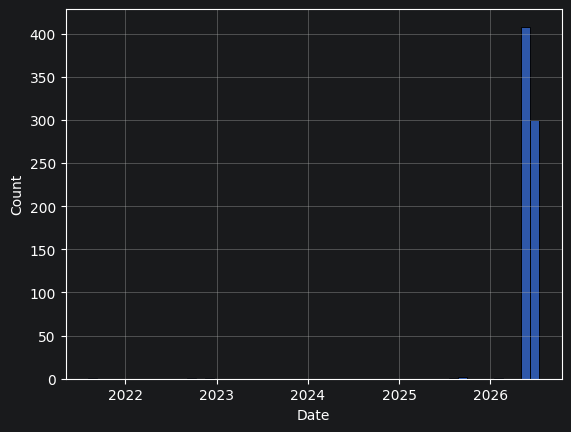

In [94]:
sns.histplot(data=data, x='date', bins=50)

plt.grid()
plt.xlabel('Date')
plt.ylabel('Count')

In [95]:
data['date'].dt.date.quantile([0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]).to_frame().T

,0.01,0.05,0.10,0.25,0.50,0.75,0.90,0.95,0.99
date,2026-05-10,2026-05-27,2026-05-30,2026-06-03,2026-06-03,2026-06-18,2026-07-01,2026-07-07,2026-07-13


In [96]:
(data
 .groupby('asset_type')
 ['amount']
 .apply(tuple)
 .to_frame()
 .assign(number=lambda df: df['amount'].apply(len))
 .assign(total=lambda df: df['amount'].apply(sum))
 .assign(amounts=lambda df: df['amount'].apply(frozenset).apply(sorted).apply(tuple))
 .drop(columns=['amount'])
 .assign(uniq_amounts=lambda df: df['amounts'].apply(len))
 .sort_values(by='number', ascending=False)
 .head(25)
 )

,number,total,amounts,uniq_amounts
asset_type,,,,
BTC,33,-136.96,"(-24.5, -9.8, -4.9, -0.98, 5.0, 10.0, 20.0)",7
XYZ,14,-181.00,"(-50.0, -25.0, -20.0, -10.0, -5.0, -1.0, 10.0)",7
ORCL,13,-110.00,"(-10.0, -5.0)",2
META,12,-85.95,"(-10.0, -5.0, -1.0, 0.05)",4
WFC,12,-56.00,"(-25.0, -10.0, -5.0, -1.0, 10.0, 20.0)",6
JPM,12,-70.00,"(-25.0, -10.0, -5.0, 10.0, 20.0)",5
AMZN,12,-221.00,"(-50.0, -25.0, -10.0, -1.0)",4
V,10,-81.00,"(-25.0, -20.0, -10.0, -5.0, -1.0, 20.0)",6
PZZA,10,-85.00,"(-25.0, -10.0, -5.0, 10.0)",4


In [97]:
data['currency'].value_counts()

currency
USD    715
Name: count, dtype: int64

In [98]:
data['trans_type'].value_counts()

trans_type
Stock Buy                    498
Deposits                      67
Stock Dividends               47
Stock Sell                    47
Bitcoin Buy                   24
Savings Internal Transfer     12
Bitcoin Sell                   9
P2P                            7
Account Notifications          3
Withdrawal                     1
Name: count, dtype: int64

In [99]:
top_assets = (
    data
    .pivot_table(index='asset_type', columns='trans_type', aggfunc='count',
                 values='net_amount', fill_value=0,
                 margins=True, margins_name='total')
    .sort_values(by='total', ascending=False)
    .head(40)
)
top_assets

trans_type,Bitcoin Buy,Bitcoin Sell,Stock Buy,Stock Dividends,Stock Sell,total
asset_type,,,,,,
total,24,9,498,47,47,625
BTC,24,9,0,0,0,33
XYZ,0,0,13,0,1,14
ORCL,0,0,13,0,0,13
AMZN,0,0,12,0,0,12
JPM,0,0,10,0,2,12
WFC,0,0,10,0,2,12
META,0,0,11,1,0,12
MCD,0,0,9,1,0,10


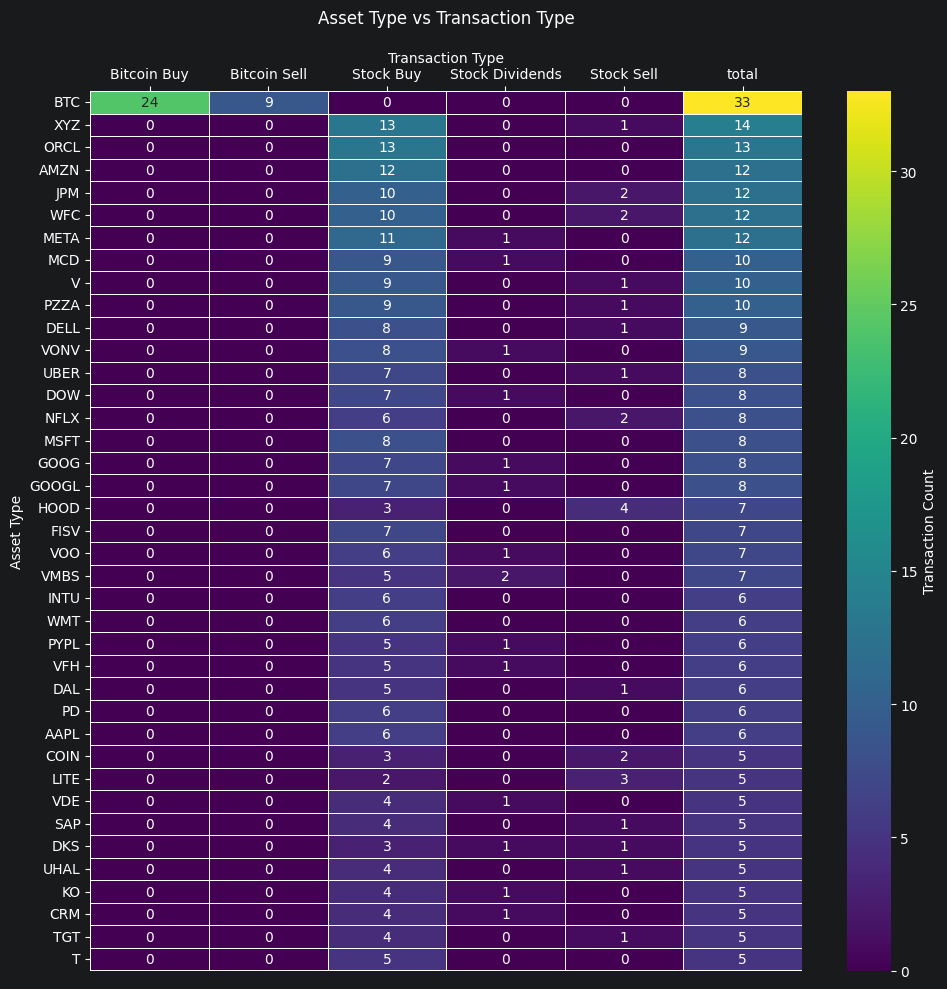

In [100]:
top_assets_heat = top_assets.drop(index='total', errors='ignore')

fig, ax = plt.subplots(figsize=(10, 10))

sns.heatmap(
    top_assets_heat,
    annot=True,
    fmt='g',
    cmap='viridis',
    linewidths=0.5,
    cbar_kws={'label': 'Transaction Count'},
    ax=ax,
)

ax.set_title('Asset Type vs Transaction Type', pad=20)
ax.set_ylabel('Asset Type', rotation=90)
ax.set_xlabel('Transaction Type', rotation=0)

ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

plt.tight_layout()


In [101]:
data_btc = data[data['asset_type'] == 'BTC']
data_btc.head()

,date,net_amount,amount,asset_price,asset_amount,fee,asset_type,trans_type,currency,trans_id,account,status,notes,name_trans
11,2026-07-11 11:26:39+00:00,9.8,10.0,63645.54,0.000157,-0.2,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00015712,NaN
17,2026-07-10 14:02:46+00:00,9.8,10.0,63970.87,0.000156,-0.2,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00015632,NaN
38,2026-07-06 16:44:23+00:00,9.8,10.0,63170.74,0.000158,-0.2,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00015830,NaN
50,2026-07-02 17:10:19+00:00,19.6,20.0,61217.07,0.000327,-0.4,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00032671,NaN
78,2026-07-01 14:21:49+00:00,-10.0,-9.8,60409.85,0.000162,-0.2,BTC,Bitcoin Buy,USD,NaN,Cash Balance,COMPLETE,purchase of BTC 0.00016223,NaN


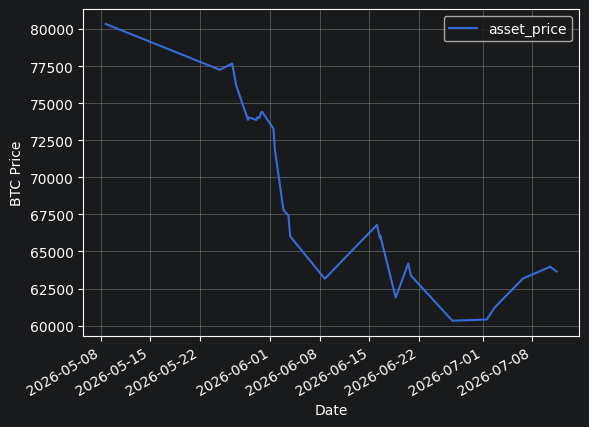

In [102]:
data_btc.plot.line(x='date', y='asset_price')
plt.xlabel('Date')
plt.ylabel('BTC Price')
plt.grid()

In [103]:
data_btc['trans_type'].value_counts()

trans_type
Bitcoin Buy     24
Bitcoin Sell     9
Name: count, dtype: int64

In [104]:
data_btc.pivot_table(index='trans_type', aggfunc='sum', values='net_amount')

,net_amount
trans_type,
Bitcoin Buy,-252.0
Bitcoin Sell,107.8


In [105]:
data_btc['net_amount'].sum()

np.float64(-144.2)

In [106]:
trans_btc = data_btc.pivot_table(index='trans_type', aggfunc='sum', values='asset_amount')['asset_amount']
trans_btc

trans_type
Bitcoin Buy     0.003420
Bitcoin Sell    0.001748
Name: asset_amount, dtype: float64

In [107]:
data_btc['asset_amount'].sum()

np.float64(0.005167250000000001)

In [108]:
btc_amount = trans_btc['Bitcoin Buy'] - trans_btc['Bitcoin Sell']
btc_amount

np.float64(0.00167199)

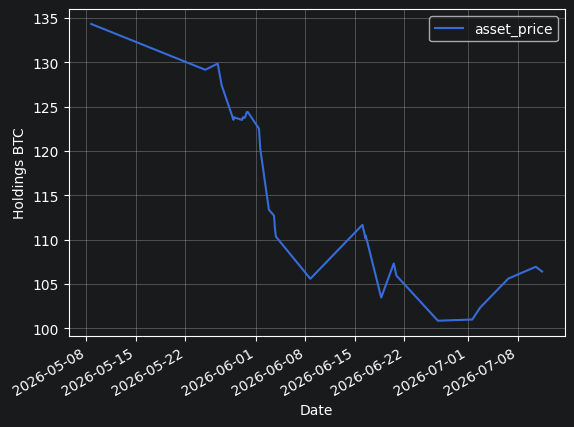

In [109]:
data_btc.assign(asset_price=lambda x: btc_amount * x['asset_price']).plot.line(x='date', y='asset_price')
plt.xlabel('Date')
plt.ylabel('Holdings BTC')
plt.grid()

In [110]:
data_btc['asset_price'] * data_btc['asset_amount']

11      9.999987
17      9.999926
38      9.999928
50     20.000229
78      9.800290
115     4.900090
170    10.000046
172     4.899747
181    19.999846
263     5.000156
264     4.999899
267     4.900240
303    19.999798
383     9.799846
410     9.800287
434     0.980144
531     9.800221
542     0.979969
559     9.799652
617     4.900136
619     9.799865
622     4.900112
623     9.799903
627     9.799965
631    24.500200
638    24.499951
642    24.500084
661     9.799731
665     9.800031
688    24.499991
705     9.799898
706     4.900356
707     9.799819
dtype: float64

In [111]:
data_xyz = data[data['asset_type'] == 'XYZ']
data_xyz

,date,net_amount,amount,asset_price,asset_amount,fee,asset_type,trans_type,currency,trans_id,account,status,notes,name_trans
33,2026-07-08 17:05:18+00:00,-10.0,-10.0,76.07,0.13145,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
114,2026-06-26 17:43:48+00:00,-10.0,-10.0,77.24,0.12946,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
143,2026-06-22 13:33:13+00:00,10.0,10.0,74.28,0.13462,0.0,XYZ,Stock Sell,USD,NaN,Cash Balance,COMPLETE,$10 Sale of Block,NaN
225,2026-06-16 13:31:47+00:00,-5.0,-5.0,74.95,0.06671,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$5 Purchase of Block,NaN
270,2026-06-15 13:32:07+00:00,-10.0,-10.0,72.26,0.13838,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
318,2026-06-04 13:31:36+00:00,-20.0,-20.0,70.84,0.28232,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$20 Purchase of Block,NaN
394,2026-06-03 19:22:37+00:00,-10.0,-10.0,69.87,0.14312,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
406,2026-06-03 16:57:03+00:00,-10.0,-10.0,69.67,0.14353,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
419,2026-06-03 15:50:14+00:00,-10.0,-10.0,69.62,0.14364,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
457,2026-06-03 13:43:52+00:00,-10.0,-10.0,71.59,0.13968,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN


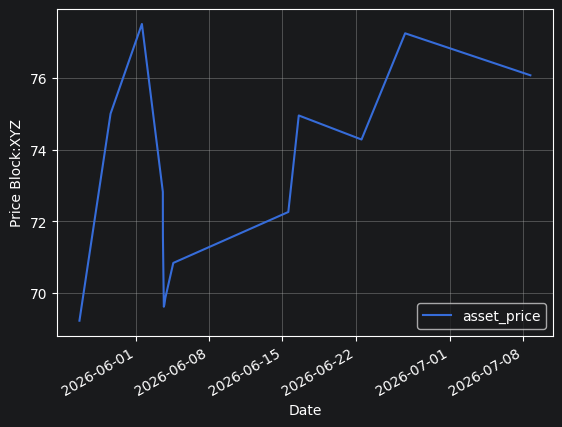

In [112]:
data_xyz.plot.line(x='date', y='asset_price')
plt.xlabel('Date')
plt.ylabel('Price Block:XYZ')
plt.grid()

In [113]:
asset_count = data.groupby('asset_type')['amount'].count().sort_values(ascending=False)
asset_count

asset_type
BTC     33
XYZ     14
ORCL    13
META    12
WFC     12
        ..
MSGS     1
UNFI     1
DASH     1
RIVN     1
ZG       1
Name: amount, Length: 168, dtype: int64

In [114]:
asset_price = data.pivot_table(index='date', columns='asset_type', aggfunc='sum', values='asset_price').bfill(axis=0)
asset_price.head()

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-05-08 16:42:34+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-24 19:57:02+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-26 14:06:39+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-26 14:09:07+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-27 03:38:54+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,75.00,149.54,42.9,36.36,36.25


In [115]:
data['asset_amount'].describe()

count    715.000000
mean       0.138751
std        0.325815
min        0.000000
25%        0.007250
50%        0.044200
75%        0.127090
max        4.509170
Name: asset_amount, dtype: float64

In [116]:
data[data['asset_type'] == 'ADP']

,date,net_amount,amount,asset_price,asset_amount,fee,asset_type,trans_type,currency,trans_id,account,status,notes,name_trans
107,2026-07-01 04:00:00+00:00,0.15,0.15,NaN,0.00000,0.0,ADP,Stock Dividends,USD,NaN,Cash Balance,COMPLETE,$0.15 Dividend from Automatic Data Processing,NaN
180,2026-06-18 17:14:10+00:00,-10.00,-10.00,217.48,0.04598,0.0,ADP,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Automatic Data Processing,NaN
444,2026-06-03 15:08:22+00:00,-10.00,-10.00,226.23,0.04420,0.0,ADP,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Automatic Data Processing,NaN
569,2026-06-01 13:30:28+00:00,-10.00,-10.00,223.99,0.04464,0.0,ADP,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Automatic Data Processing,NaN


In [117]:
stock_amount_direction = {'Stock Sell': -1, 'Stock Buy': 1}
asset_holding_time = (
    data
    [data['trans_type'].isin(stock_amount_direction.keys())]
    .assign(stock_direction=lambda x: x['trans_type'].map(stock_amount_direction))
    .assign(asset_amount=lambda x: x['asset_amount'] * x['stock_direction'])
    .pivot_table(index='date', columns='asset_type', aggfunc='sum', values='asset_amount')
    .fillna(0)
    .cumsum(axis=0)
    .mul(asset_price, axis=1)
    .dropna(how='all')
    .ffill(axis=0)
    .sort_index()
)
asset_holding_time.sample(10, random_state=0xCAFE).sort_index()

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-06-03 16:17:25+00:00,20.147721,9.999493,9.010079,8.379889,19.320923,9.999577,20.893584,0.000000,14.039852,0.000000,...,0.000000,41.665912,9.686363,27.762524,0.0,109.742791,19.945984,9.953370,0.000000,0.000000
2026-06-03 19:20:29+00:00,20.147721,9.999493,9.010079,8.379889,19.320923,9.999577,20.893584,0.000000,14.039852,0.000000,...,0.000000,51.890247,18.724670,27.762524,0.0,120.086268,19.945984,9.953370,0.000000,0.000000
2026-06-16 13:31:37+00:00,28.691891,9.999493,11.181242,8.379889,19.320923,9.999577,20.893584,11.051107,14.039852,20.071824,...,0.000000,77.322328,18.724670,27.762524,0.0,171.075624,30.191289,9.953370,9.999727,9.999925
2026-06-18 14:10:06+00:00,28.691891,9.999493,11.181242,8.379889,19.320923,9.999577,20.893584,11.051107,14.039852,20.071824,...,0.000000,81.303113,23.724046,27.762524,0.0,174.501547,30.191289,9.953370,9.999727,9.999925
2026-06-22 13:30:44+00:00,37.937295,9.999493,16.180396,8.379889,0.000000,9.999577,20.893584,21.050186,9.042617,20.071824,...,0.000000,85.406771,23.724046,27.762524,0.0,174.501547,42.997334,19.954137,9.999727,9.999925
2026-06-23 17:26:24+00:00,37.937295,9.999493,16.180396,8.379889,0.000000,9.999577,20.893584,21.050186,9.042617,30.069556,...,20.007326,75.498388,23.724046,27.762524,0.0,171.057249,42.997334,19.954137,9.999727,9.999925
2026-07-01 19:14:58+00:00,51.311805,9.999493,16.180396,8.379889,0.000000,9.999577,20.893584,21.050186,9.042617,30.069556,...,6.862441,58.199610,23.724046,39.646701,0.0,178.314166,52.997013,19.954137,9.999727,9.999925
2026-07-02 14:54:10+00:00,51.311805,9.999493,16.180396,8.379889,0.000000,9.999577,0.000000,21.050186,9.042617,30.069556,...,6.862441,58.199610,23.724046,39.646701,0.0,178.314166,52.997013,19.954137,9.999727,9.999925
2026-07-06 16:42:10+00:00,61.309073,9.999493,16.180396,8.379889,0.000000,9.999577,0.000000,21.050186,9.042617,30.069556,...,6.862441,58.199610,23.724046,39.646701,0.0,178.314166,52.997013,19.954137,9.999727,9.999925


In [118]:
asset_holding_time.iloc[-1].sum(axis=0)

np.float64(3977.562136)

In [119]:
asset_holding_time_last = asset_holding_time.iloc[-1].sort_values(ascending=False)
asset_holding_time_last.head()

asset_type
AMZN    212.311076
XYZ     188.313567
DELL    117.932301
MCD      98.010046
UBER     96.165081
Name: 2026-07-15 13:30:02+00:00, dtype: float64

In [120]:
asset_holding_time_last.tail()

asset_type
POR     0.0
VBR     0.0
ILMN    0.0
JEPI    0.0
BTC     NaN
Name: 2026-07-15 13:30:02+00:00, dtype: float64

In [121]:
zero_assets = asset_holding_time_last[asset_holding_time_last == 0.0].sort_index().index
zero_assets

Index(['ADP', 'ALKT', 'AVGO', 'BBEU', 'BIV', 'BNDX', 'CRM', 'CXSE', 'DKS',
       'EMB', 'FIS', 'GM', 'GSLC', 'HPQ', 'ILMN', 'JEPI', 'KO', 'KWEB', 'LECO',
       'MRK', 'NOBL', 'NVDA', 'OWL', 'OXY', 'POR', 'PSKY', 'QCOM', 'RUM',
       'RUN', 'TMO', 'TSM', 'VBR', 'VDC', 'VFH', 'VHT', 'VMBS', 'VNQ', 'VONG',
       'VSS', 'VTEB', 'XLB'],
      dtype='str', name='asset_type')

In [122]:
data[data['asset_type'].isin(zero_assets)][['asset_type', 'notes']].sort_values('asset_type')

,asset_type,notes
569,ADP,$10 Purchase of Automatic Data Processing
444,ADP,$10 Purchase of Automatic Data Processing
107,ADP,$0.15 Dividend from Automatic Data Processing
180,ADP,$10 Purchase of Automatic Data Processing
473,ALKT,$10 Purchase of Alkami Technology
...,...,...
202,VTEB,$5 Purchase of Vanguard Tax-Exempt Bond ETF
47,VTEB,$0.04 Dividend from Vanguard Tax-Exempt Bond ETF
606,VTEB,$10 Purchase of Vanguard Tax-Exempt Bond ETF
132,XLB,$0.04 Dividend from Materials Select Sector SPDR


In [123]:
asset_price_rel = asset_holding_time.div(asset_holding_time.iloc[-1].sum(axis=0))
asset_price_rel.tail(5)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-07-13 13:30:22+00:00,0.015414,0.002514,0.004068,0.00462,0.0,0.002514,0.0,0.005292,0.002273,0.00756,...,0.001725,0.015889,0.005964,0.014859,0.0,0.047344,0.013324,0.005017,0.002514,0.002514
2026-07-13 13:30:23+00:00,0.015414,0.002514,0.004068,0.00462,0.0,0.002514,0.0,0.005292,0.002273,0.00756,...,0.001725,0.015889,0.005964,0.014859,0.0,0.047344,0.013324,0.005017,0.002514,0.002514
2026-07-13 13:30:27+00:00,0.015414,0.002514,0.004068,0.00462,0.0,0.002514,0.0,0.005292,0.002273,0.00756,...,0.001725,0.015889,0.005964,0.014859,0.0,0.047344,0.013324,0.005017,0.002514,0.002514
2026-07-13 13:33:19+00:00,0.015414,0.002514,0.004068,0.00462,0.0,0.002514,0.0,0.005292,0.002273,0.00756,...,0.001725,0.015889,0.005964,0.014859,0.0,0.047344,0.013324,0.005017,0.002514,0.002514
2026-07-15 13:30:02+00:00,0.015414,0.002514,0.004068,0.00462,0.0,0.002514,0.0,0.005292,0.002273,0.00756,...,0.001725,0.015889,0.005964,0.014859,0.0,0.047344,0.013324,0.005017,0.002514,0.002514


In [124]:
asset_price_rel.iloc[-1].describe()

count    167.000000
mean       0.005988
std        0.007755
min        0.000000
25%        0.001805
50%        0.003885
75%        0.007406
max        0.053377
Name: 2026-07-15 13:30:02+00:00, dtype: float64

In [125]:
asset_price_rel_last = asset_price_rel.iloc[-1].sort_values(ascending=False)
asset_price_rel_last.head()

asset_type
AMZN    0.053377
XYZ     0.047344
DELL    0.029649
MCD     0.024641
UBER    0.024177
Name: 2026-07-15 13:30:02+00:00, dtype: float64

In [126]:
asset_price_rel_last.tail()

asset_type
POR     0.0
VBR     0.0
ILMN    0.0
JEPI    0.0
BTC     NaN
Name: 2026-07-15 13:30:02+00:00, dtype: float64

<Axes: ylabel='Frequency'>

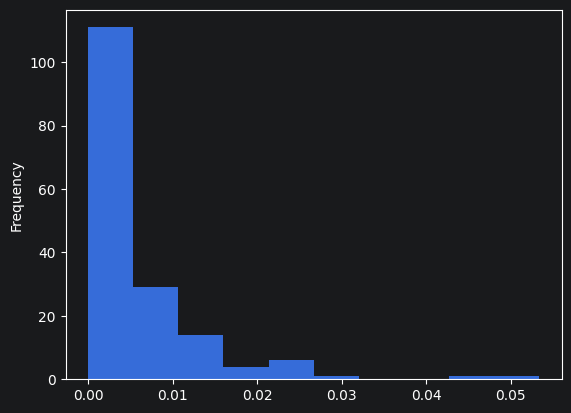

In [127]:
asset_price_rel_last.plot.hist()

In [128]:
asset_price_rel.tail(5)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-07-13 13:30:22+00:00,0.015414,0.002514,0.004068,0.00462,0.0,0.002514,0.0,0.005292,0.002273,0.00756,...,0.001725,0.015889,0.005964,0.014859,0.0,0.047344,0.013324,0.005017,0.002514,0.002514
2026-07-13 13:30:23+00:00,0.015414,0.002514,0.004068,0.00462,0.0,0.002514,0.0,0.005292,0.002273,0.00756,...,0.001725,0.015889,0.005964,0.014859,0.0,0.047344,0.013324,0.005017,0.002514,0.002514
2026-07-13 13:30:27+00:00,0.015414,0.002514,0.004068,0.00462,0.0,0.002514,0.0,0.005292,0.002273,0.00756,...,0.001725,0.015889,0.005964,0.014859,0.0,0.047344,0.013324,0.005017,0.002514,0.002514
2026-07-13 13:33:19+00:00,0.015414,0.002514,0.004068,0.00462,0.0,0.002514,0.0,0.005292,0.002273,0.00756,...,0.001725,0.015889,0.005964,0.014859,0.0,0.047344,0.013324,0.005017,0.002514,0.002514
2026-07-15 13:30:02+00:00,0.015414,0.002514,0.004068,0.00462,0.0,0.002514,0.0,0.005292,0.002273,0.00756,...,0.001725,0.015889,0.005964,0.014859,0.0,0.047344,0.013324,0.005017,0.002514,0.002514


In [129]:
asset_price_time = (
    data
    .pivot_table(index='date', columns='asset_type', aggfunc='median', values='asset_price')
    .dropna(how='all')
)
asset_price_time.sample(10, random_state=0xCAFE)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-05-27 13:30:01+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-07-10 13:31:04+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-16 13:30:13+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-16 13:30:02+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-07-10 13:30:21+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-03 19:20:16+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-07-10 13:30:04+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-07-02 13:30:06+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-03 15:15:33+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [130]:
asset_price_rel = asset_price_time.div(asset_price_time.bfill().iloc[0]).ffill().fillna(1)
asset_price_rel.sample(10, random_state=0xCAFE)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-05-27 13:30:01+00:00,1.000000,1.0,1.000000,1.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.0,1.0
2026-07-10 13:31:04+00:00,1.017280,1.0,0.719207,0.838148,0.970936,1.0,1.020619,1.105111,1.404207,1.003791,...,1.342357,1.072471,0.921293,0.939144,1.0,1.098801,1.075766,0.995338,1.0,1.0
2026-06-16 13:30:13+00:00,1.018386,1.0,1.000000,1.000000,1.010000,1.0,0.954965,1.000000,1.000000,1.000000,...,1.000000,1.035138,0.968648,0.976969,1.0,1.043767,0.997325,1.000000,1.0,1.0
2026-06-16 13:30:02+00:00,1.018386,1.0,1.000000,1.000000,1.010000,1.0,0.954965,1.000000,1.000000,1.000000,...,1.000000,1.035138,0.968648,0.976969,1.0,1.043767,0.997325,1.000000,1.0,1.0
2026-07-10 13:30:21+00:00,1.017280,1.0,0.719207,0.838148,0.970936,1.0,1.020619,1.105111,1.404207,1.003791,...,1.342357,1.072471,0.921293,0.939144,1.0,1.098801,1.075766,0.995338,1.0,1.0
2026-06-03 19:20:16+00:00,1.021803,1.0,1.000000,1.000000,1.010000,1.0,0.954965,1.000000,1.000000,1.000000,...,1.000000,1.012014,0.968648,0.976969,1.0,1.006356,1.000000,1.000000,1.0,1.0
2026-07-10 13:30:04+00:00,1.017280,1.0,0.719207,1.000000,0.970936,1.0,1.020619,1.105111,1.404207,1.003791,...,1.342357,1.072471,0.921293,0.939144,1.0,1.098801,1.075766,0.995338,1.0,1.0
2026-07-02 13:30:06+00:00,0.950374,1.0,0.719207,1.000000,0.970936,1.0,0.954965,1.105111,1.404207,1.003791,...,1.342357,1.072471,0.921293,0.904346,1.0,1.115701,1.075766,0.995338,1.0,1.0
2026-06-03 15:15:33+00:00,1.021803,1.0,1.000000,1.000000,1.010000,1.0,0.954965,1.000000,1.000000,1.000000,...,1.000000,1.008655,1.000000,0.976969,1.0,1.034089,1.000000,1.000000,1.0,1.0


Text(0, 0.5, 'Relative Value of Asset Price')

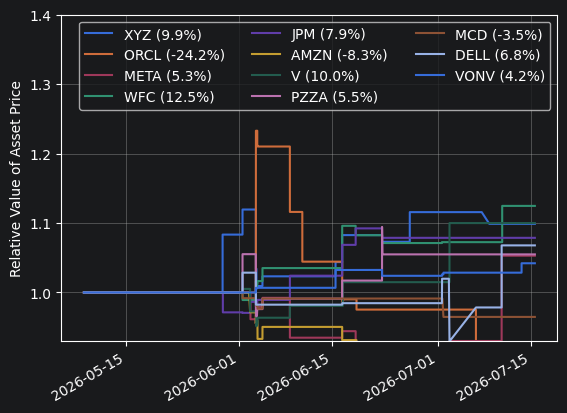

In [131]:
asset_price_rel_plot = asset_price_rel[asset_count.head(12).iloc[1::].index].copy()
asset_price_rel_plot_perc = asset_price_rel_plot.iloc[-1].sub(1).mul(100).round(1)
asset_price_rel_plot.columns = [f'{col} ({perc}%)' for col, perc in
                                zip(asset_price_rel_plot.columns, asset_price_rel_plot_perc)]
asset_price_rel_plot.plot.line()
plt.grid()
plt.legend(ncols=3, loc='upper right')
plt.ylim(0.93, 1.4)
plt.xlabel('')
plt.ylabel('Relative Value of Asset Price')

In [132]:
asset_price_rel['XYZ'].dropna()

date
2026-05-08 16:42:34+00:00    1.000000
2026-05-24 19:57:02+00:00    1.000000
2026-05-26 14:06:39+00:00    1.000000
2026-05-26 14:09:07+00:00    1.000000
2026-05-27 03:38:54+00:00    1.000000
                               ...   
2026-07-13 13:30:22+00:00    1.098801
2026-07-13 13:30:23+00:00    1.098801
2026-07-13 13:30:27+00:00    1.098801
2026-07-13 13:33:19+00:00    1.098801
2026-07-15 13:30:02+00:00    1.098801
Name: XYZ, Length: 455, dtype: float64

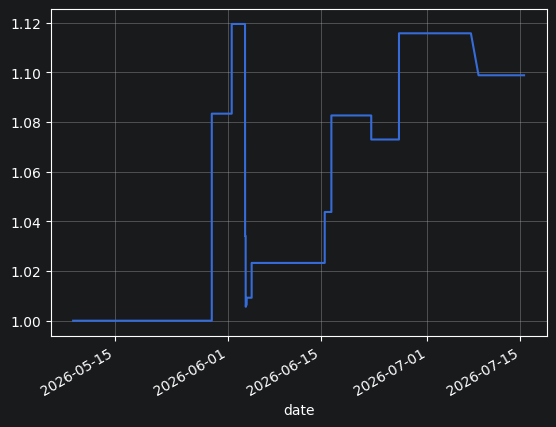

In [133]:
asset_price_rel['XYZ'].dropna().plot.line()
plt.grid()


In [134]:
div_data = (
    data[data['trans_type'] == 'Stock Dividends']
    .drop(columns=['asset_amount', 'fee', 'asset_price', 'trans_id', 'name_trans', 'account', 'currency', 'status',
                   'trans_type', 'net_amount'])
    .assign(date=lambda x: x['date'].dt.date)
    .sort_values('date', ascending=False)
)
div_data

,date,amount,asset_type,notes
1,2026-07-15,0.03,LECO,$0.03 Dividend from Lincoln Electric
3,2026-07-15,0.16,OXY,$0.16 Dividend from Occidental Petroleum
4,2026-07-15,0.11,POR,$0.11 Dividend from Portland General Electric ...
2,2026-07-15,0.01,TMO,$0.01 Dividend from Thermo Fisher Scientific
30,2026-07-09,0.02,TSM,$0.02 Dividend from Taiwan Semiconductor Manuf...
34,2026-07-08,0.07,MRK,$0.07 Dividend from Merck
44,2026-07-06,0.04,BIV,$0.04 Dividend from Vanguard Intermediate Term...
45,2026-07-06,0.07,JEPI,$0.07 Dividend from JPMorgan Equity Premium In...
46,2026-07-06,0.05,BNDX,$0.05 Dividend from Vanguard Total Internation...
47,2026-07-06,0.04,VTEB,$0.04 Dividend from Vanguard Tax-Exempt Bond ETF


In [135]:
div_data['amount'].sum()

np.float64(4.34)

In [136]:
div_data.sort_values('amount', ascending=False)

,date,amount,asset_type,notes
119,2026-06-26,0.30,VFH,$0.30 Dividend from Vanguard Financials ETF
104,2026-07-01,0.27,HPQ,$0.27 Dividend from Hewlett Packard
126,2026-06-25,0.26,BBEU,$0.26 Dividend from JPMorgan BetaBuilders Euro...
265,2026-06-16,0.20,MCD,$0.20 Dividend from McDonald's
122,2026-06-26,0.20,VDE,$0.20 Dividend from Energy ETF Vanguard
116,2026-06-26,0.18,VNQ,$0.18 Dividend from Vanguard Real Estate ETF
105,2026-07-01,0.17,KO,$0.17 Dividend from Coca-Cola
117,2026-06-26,0.17,DKS,$0.17 Dividend from Dick's Sporting Goods
3,2026-07-15,0.16,OXY,$0.16 Dividend from Occidental Petroleum
136,2026-06-23,0.16,VSS,$0.16 Dividend from Vanguard FTSE All World ex...


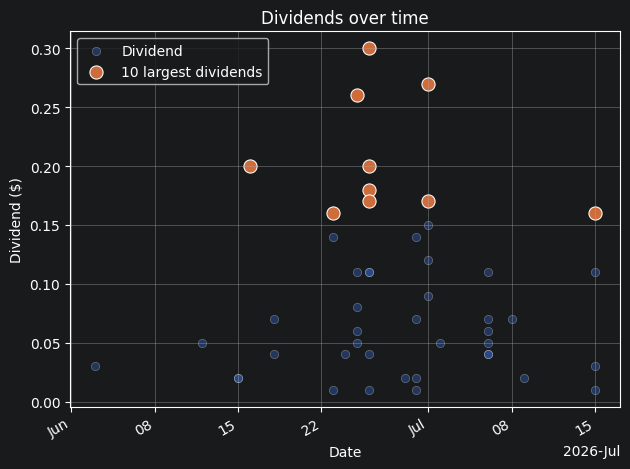

In [137]:
d = div_data.copy()
d["Date"] = pd.to_datetime(d["date"])
d = d.sort_values("date")

top10 = d.nlargest(10, "amount")

ax = sns.scatterplot(
    data=d,
    x="date",
    y="amount",
    alpha=0.35,
    label="Dividend",
)

sns.scatterplot(
    data=top10,
    x="date",
    y="amount",
    s=90,
    ax=ax,
    label="10 largest dividends",
)

for _, r in top10.iterrows():
    ax.annotate(
        r["asset_type"],
        (r["date"], r["date"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
    )

ax.set_title("Dividends over time")
ax.set_xlabel("Date")
ax.set_ylabel("Dividend ($)")

ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))

ax.legend()
plt.grid()
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

In [138]:
vanguard_data = (
    data[
        data['notes']
        .str.lower()
        .str.contains('vanguard')
    ]
    [['date', 'net_amount', 'asset_price', 'notes', 'asset_type']]
)
vanguard_data.sample(10, random_state=0xCAFE)


,date,net_amount,asset_price,notes,asset_type
590,2026-06-01 13:30:16+00:00,-25.00,160.89,$25 Purchase of Energy ETF Vanguard,VDE
134,2026-06-23 04:00:00+00:00,0.01,NaN,$0.01 Dividend from Vanguard Russell 1000 Grow...,VONG
6,2026-07-13 13:30:27+00:00,-10.00,108.50,$10 Purchase of Vanguard Russell 1000 Value ETF,VONV
253,2026-06-16 13:30:05+00:00,-5.00,132.21,$5 Purchase of Vanguard Financials ETF,VFH
421,2026-06-03 15:49:05+00:00,-10.00,275.30,$10 Purchase of Vanguard Health Care ETF,VHT
476,2026-06-03 13:30:16+00:00,-10.00,104.82,$10 Purchase of Vanguard Russell 1000 Value ETF,VONV
485,2026-06-03 13:30:12+00:00,-1.00,46.56,$1 Purchase of Vanguard Mortgage-Backed Securi...,VMBS
420,2026-06-03 15:49:42+00:00,-10.00,124.12,$10 Purchase of Vanguard Financials ETF,VFH
187,2026-06-18 17:09:02+00:00,-10.00,126.88,$10 Purchase of Vanguard Russell 1000 Growth ETF,VONG
477,2026-06-03 13:30:16+00:00,-10.00,697.19,$10 Purchase of Vanguard S&P 500 ETF,VOO


In [139]:
vanguard_trans_count = vanguard_data['asset_type'].value_counts()
vanguard_trans_count

asset_type
VONV    9
VOO     7
VMBS    7
VFH     6
VDE     5
VGLT    4
VCR     4
VNQ     4
VHT     4
VSS     4
BIV     3
BNDX    3
VTEB    3
VBR     3
VDC     3
VONG    3
BSV     1
Name: count, dtype: int64

In [140]:
vanguard_note_name = (
    vanguard_data['notes']
    .pipe(lambda x: x[x.str.contains('Purchase')])
    .str.replace('.*Purchase of', '', regex=True)
)
vanguard_data_asset_names = (
    vanguard_data
    .assign(name=vanguard_note_name)
    .drop(columns=['notes'])
)
vanguard_data_asset_names.sample(10, random_state=0xCAFE)

,date,net_amount,asset_price,asset_type,name
590,2026-06-01 13:30:16+00:00,-25.00,160.89,VDE,Energy ETF Vanguard
134,2026-06-23 04:00:00+00:00,0.01,NaN,VONG,NaN
6,2026-07-13 13:30:27+00:00,-10.00,108.50,VONV,Vanguard Russell 1000 Value ETF
253,2026-06-16 13:30:05+00:00,-5.00,132.21,VFH,Vanguard Financials ETF
421,2026-06-03 15:49:05+00:00,-10.00,275.30,VHT,Vanguard Health Care ETF
476,2026-06-03 13:30:16+00:00,-10.00,104.82,VONV,Vanguard Russell 1000 Value ETF
485,2026-06-03 13:30:12+00:00,-1.00,46.56,VMBS,Vanguard Mortgage-Backed Securities ETF
420,2026-06-03 15:49:42+00:00,-10.00,124.12,VFH,Vanguard Financials ETF
187,2026-06-18 17:09:02+00:00,-10.00,126.88,VONG,Vanguard Russell 1000 Growth ETF
477,2026-06-03 13:30:16+00:00,-10.00,697.19,VOO,Vanguard S&P 500 ETF


In [141]:
vanguard_data_asset_names_trans_count = (
    vanguard_data_asset_names
    .groupby(['asset_type', 'name'])
    ['date']
    .count()
    .sort_values(ascending=False)
)
vanguard_data_asset_names_trans_count

asset_type  name                                       
VONV        Vanguard Russell 1000 Value ETF                8
VOO         Vanguard S&P 500 ETF                           6
VFH         Vanguard Financials ETF                        5
VMBS        Vanguard Mortgage-Backed Securities ETF        5
VDE         Energy ETF Vanguard                            4
VGLT        Vanguard Long-Treasury ETF                     3
VSS         Vanguard FTSE All World ex US Small Cap ETF    3
VCR         Vanguard Consumer Discretionary ETF            3
VHT         Vanguard Health Care ETF                       3
VNQ         Vanguard Real Estate ETF                       2
VONG        Vanguard Russell 1000 Growth ETF               2
BIV         Vanguard Intermediate Term Bond ETF            2
BNDX        Vanguard Total International Bond ETF          2
VDC         Vanguard Consumer Staples Index Fund ETF       2
VBR         Small Cap Value ETF Vanguard                   2
VTEB        Vanguard Tax-Exem

In [142]:
vanguard_asset_price_time = asset_holding_time = (
    vanguard_data
    .pivot_table(index='date', columns='asset_type', aggfunc='median', values='asset_price')
    [vanguard_trans_count.index]
    .dropna(how='all')
)
vanguard_asset_price_time

asset_type,VONV,VOO,VMBS,VFH,VDE,VGLT,VCR,VNQ,VHT,VSS,BIV,BNDX,VTEB,VBR,VDC,VONG,BSV
date,,,,,,,,,,,,,,,,,
2026-05-29 14:26:46+00:00,NaN,NaN,46.86,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:01+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,233.47,NaN,NaN,NaN
2026-06-01 13:30:04+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50.12,NaN,NaN,NaN,NaN
2026-06-01 13:30:06+00:00,NaN,NaN,46.56,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:10+00:00,NaN,NaN,NaN,NaN,NaN,NaN,397.97,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:11+00:00,NaN,NaN,NaN,125.85,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:15+00:00,104.12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:16+00:00,NaN,NaN,NaN,NaN,160.89,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:23+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,95.08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [143]:
vanguard_trans_count

asset_type
VONV    9
VOO     7
VMBS    7
VFH     6
VDE     5
VGLT    4
VCR     4
VNQ     4
VHT     4
VSS     4
BIV     3
BNDX    3
VTEB    3
VBR     3
VDC     3
VONG    3
BSV     1
Name: count, dtype: int64

Text(0, 0.5, 'Relative Value of Asset Price')

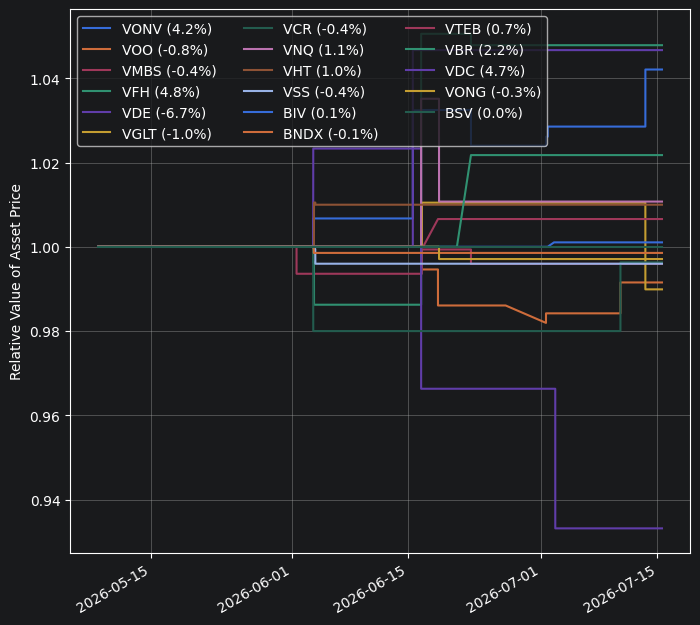

In [144]:
asset_price_rel_plot = asset_price_rel[list(vanguard_trans_count.index)].copy()
asset_price_rel_plot_perc = asset_price_rel_plot.iloc[-1].sub(1).mul(100).round(1)
asset_price_rel_plot.columns = [f'{col} ({perc}%)' for col, perc in
                                zip(asset_price_rel_plot.columns, asset_price_rel_plot_perc)]
fig, ax = plt.subplots(figsize=(8, 8))

asset_price_rel_plot.plot.line(ax=ax)
plt.grid()
plt.legend(ncols=3, loc='upper left')
plt.xlabel('')
plt.ylabel('Relative Value of Asset Price')

In [145]:
data_deposits = data[data['trans_type'] == 'Deposits'][['date', 'net_amount', 'account', 'status', 'notes']]
data_deposits

,date,net_amount,account,status,notes
12,2026-07-10 21:11:17+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
28,2026-07-10 13:17:39+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
69,2026-07-01 20:14:16+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
94,2026-07-01 13:41:36+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
169,2026-06-21 21:31:19+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
...,...,...,...,...,...
699,2026-05-27 00:56:27+00:00,100.0,Visa debit 5895,FAILED,Add Cash
700,2026-05-27 00:56:05+00:00,10.0,Visa debit 5895,COMPLETE,Add Cash
701,2026-05-27 00:43:01+00:00,50.0,Visa debit 5895,COMPLETE,Add Cash
702,2026-05-26 21:58:29+00:00,20.0,Visa debit 5895,COMPLETE,Add Cash


In [146]:
data_deposits['net_amount'].sum()

np.float64(5935.96)

In [147]:
data_deposits['net_amount'].describe().to_frame().T

,count,mean,std,min,25%,50%,75%,max
net_amount,67.0,88.596418,49.239706,1.0,50.0,100.0,100.0,200.0


In [148]:
data_deposits['net_amount'].cumsum()

12      100.00
28      200.00
69      300.00
94      400.00
169     500.00
        ...   
699    5830.96
700    5840.96
701    5890.96
702    5910.96
703    5935.96
Name: net_amount, Length: 67, dtype: float64

In [149]:
(data_deposits
.sort_values('date')
.assign(net_amount=lambda x: x['net_amount'].cumsum())
[['date', 'net_amount']]
)

,date,net_amount
703,2026-05-26 19:39:34+00:00,25.00
702,2026-05-26 21:58:29+00:00,45.00
701,2026-05-27 00:43:01+00:00,95.00
700,2026-05-27 00:56:05+00:00,105.00
699,2026-05-27 00:56:27+00:00,205.00
...,...,...
169,2026-06-21 21:31:19+00:00,5535.96
94,2026-07-01 13:41:36+00:00,5635.96
69,2026-07-01 20:14:16+00:00,5735.96
28,2026-07-10 13:17:39+00:00,5835.96


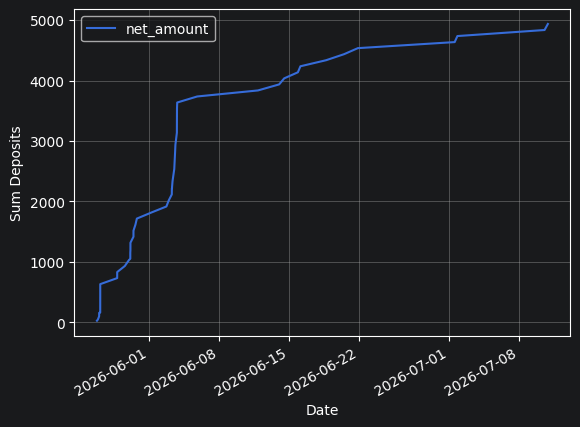

In [150]:
(data_deposits
 .sort_values('date')
 .pipe(lambda x: x[x['status'] != 'FAILED'])
 .assign(net_amount=lambda x: x['net_amount'].cumsum())
 .plot.line(x='date', y='net_amount')
 )
plt.xlabel('Date')
plt.ylabel('Sum Deposits')
plt.grid()

In [151]:
(data_deposits
 .sort_values('date')
 .pipe(lambda x: x[x['status'] != 'FAILED'])
 .pivot_table(index='date', columns='account', values='net_amount', aggfunc='sum', fill_value=0)
 )

account,Visa debit 3333,Visa debit 5895
date,,
2026-05-26 19:39:34+00:00,0.0,25.00
2026-05-26 21:58:29+00:00,0.0,20.00
2026-05-27 00:43:01+00:00,0.0,50.00
2026-05-27 00:56:05+00:00,0.0,10.00
2026-05-27 00:57:28+00:00,0.0,50.00
2026-05-27 03:29:11+00:00,0.0,5.00
2026-05-27 03:29:39+00:00,0.0,10.00
2026-05-27 03:30:06+00:00,0.0,10.00
2026-05-27 03:30:50+00:00,0.0,50.00


In [152]:
(data_deposits
 .pipe(lambda x: x[x['status'] != 'FAILED'])
 .groupby('account')
 ['net_amount']
 .sum()
 )

account
Visa debit 3333    4600.00
Visa debit 5895     335.96
Name: net_amount, dtype: float64